**Step 1-Inspecting the dataset(EDA)**

In [3]:
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt

# 1. Check the current Google Colab working directory
print(f"Current working directory: {os.getcwd()}\n")

# Directly assign the paths provided by the user
dataset_root = '/content'
cancer_path = '/content/cancer'
non_cancer_path = '/content/non-cancer'

if os.path.exists(cancer_path) and os.path.exists(non_cancer_path):
    print(f"Dataset root directory found at: {dataset_root}")
    print(f"Cancer images path: {cancer_path}")
    print(f"Non-cancer images path: {non_cancer_path}")
else:
    print("Error: 'cancer' or 'non-cancer' folders not found at the specified paths.")
    print("Please ensure the paths are correct and the folders exist.")
    # Reset paths to None if not found, to indicate an issue
    cancer_path = None
    non_cancer_path = None
    dataset_root = None

# Store paths for later use
%store cancer_path
%store non_cancer_path
%store dataset_root

image_extensions = ('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.tiff', '.webp')
%store image_extensions

Current working directory: c:\Users\Admin\OneDrive\Desktop

Error: 'cancer' or 'non-cancer' folders not found at the specified paths.
Please ensure the paths are correct and the folders exist.
Stored 'cancer_path' (NoneType)
Stored 'non_cancer_path' (NoneType)
Stored 'dataset_root' (NoneType)
Stored 'image_extensions' (tuple)


In [ ]:
import os
from PIL import Image

# ============================================================
# SET YOUR DATASET PATHS HERE
# ============================================================

cancer_path = r"C:\Users\Admin\path\to\cancer"
non_cancer_path = r"C:\Users\Admin\path\to\non_cancer"

# Image extensions to check
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")


# ============================================================
# FUNCTION TO CHECK IMAGES
# ============================================================

def get_image_info(path, label, extensions):
    image_files = []
    corrupted_files = []
    file_extensions = set()

    if not path or not os.path.exists(path):
        print(f"WARNING: Path not found for {label}: {path}")
        return image_files, corrupted_files, file_extensions

    for root, _, files in os.walk(path):
        for file in files:

            if file.lower().endswith(extensions):

                filepath = os.path.join(root, file)
                file_extensions.add(
                    os.path.splitext(file)[1].lower()
                )

                try:
                    img = Image.open(filepath)
                    img.verify()

                    image_files.append(filepath)

                except Exception:
                    corrupted_files.append(filepath)

    return image_files, corrupted_files, file_extensions


# ============================================================
# CHECK DATASET
# ============================================================

print("\n--- Dataset Image Counts, Extensions, and Sample Filenames ---")

cancer_image_files, cancer_corrupted_files, cancer_extensions = \
    get_image_info(
        cancer_path,
        "cancer",
        image_extensions
    )

non_cancer_image_files, non_cancer_corrupted_files, non_cancer_extensions = \
    get_image_info(
        non_cancer_path,
        "non cancer",
        image_extensions
    )


# ============================================================
# IMAGE COUNTS
# ============================================================

print(f"\nNumber of 'cancer' images found: {len(cancer_image_files)}")
print(f"Number of 'non cancer' images found: {len(non_cancer_image_files)}")


# ============================================================
# IMAGE EXTENSIONS
# ============================================================

all_extensions = cancer_extensions.union(non_cancer_extensions)

if all_extensions:
    print(
        f"\nImage extensions found: "
        f"{', '.join(sorted(all_extensions))}"
    )
else:
    print("\nNo image extensions found.")


# ============================================================
# FIRST 10 CANCER IMAGES
# ============================================================

print("\nFirst 10 'cancer' image filenames:")

for img_path in cancer_image_files[:10]:
    print(f"  {os.path.basename(img_path)}")


# ============================================================
# FIRST 10 NON-CANCER IMAGES
# ============================================================

print("\nFirst 10 'non cancer' image filenames:")

for img_path in non_cancer_image_files[:10]:
    print(f"  {os.path.basename(img_path)}")


# ============================================================
# CORRUPTED FILE CHECK
# ============================================================

print("\n--- Corrupted/Unreadable Files (Initial Check) ---")

if cancer_corrupted_files:

    print(
        f"Corrupted/Unreadable 'cancer' images found: "
        f"{len(cancer_corrupted_files)}"
    )

    for f in cancer_corrupted_files[:5]:
        print(f"  {f}")

else:
    print(
        "No corrupted/unreadable 'cancer' images found "
        "in this initial check."
    )


if non_cancer_corrupted_files:

    print(
        f"Corrupted/Unreadable 'non cancer' images found: "
        f"{len(non_cancer_corrupted_files)}"
    )

    for f in non_cancer_corrupted_files[:5]:
        print(f"  {f}")

else:
    print(
        "No corrupted/unreadable 'non cancer' images found "
        "in this initial check."
    )


# ============================================================
# STORE FOR LATER CELLS
# ============================================================

%store cancer_path
%store non_cancer_path
%store image_extensions

%store cancer_image_files
%store non_cancer_image_files
%store cancer_corrupted_files
%store non_cancer_corrupted_files

print("\nDataset paths and image lists stored successfully.")


--- Dataset Image Counts, Extensions, and Sample Filenames ---


TypeError: _path_exists: path should be string, bytes, os.PathLike or integer, not NoneType

In [ ]:
# Retrieve stored image file lists
%store -r cancer_image_files
%store -r non_cancer_image_files

# 8. Display sample images from both classes with their labels
# 9. Print image dimensions and color channels

def display_and_info_images(image_paths, label, num_samples=5):
    print(f"\n--- Sample {label.capitalize()} Images ---")
    fig, axes = plt.subplots(1, num_samples, figsize=(20, 5))
    if num_samples == 1:
        axes = [axes]

    for i, img_path in enumerate(image_paths[:num_samples]):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(f"{label.capitalize()}\n{os.path.basename(img_path)}")
            axes[i].axis('off')

            # Print dimensions and color channels
            width, height = img.size
            channels = len(img.getbands())
            print(f"  {os.path.basename(img_path)}: Dimensions: {width}x{height}, Channels: {channels}")
        except Exception as e:
            print(f"  Could not load/display {os.path.basename(img_path)}: {e}")
            axes[i].set_title(f"Error loading {label}")
            axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# Display 5 sample cancer images
display_and_info_images(cancer_image_files, 'cancer', num_samples=5)

# Display 5 sample non-cancer images
display_and_info_images(non_cancer_image_files, 'non cancer', num_samples=5)

**Step 2-Preparing and Splitting the data for training and testing.**

In [6]:
!pip install tqdm


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
# ============================================================
# ORAL CANCER DATASET SETUP — ALL IN ONE CELL
# ============================================================

# Install required package
import sys
!{sys.executable} -m pip install tqdm -q

# Imports
import os
from tqdm import tqdm

# ------------------------------------------------------------
# 1. SET YOUR DATASET FOLDER PATHS
# ------------------------------------------------------------
cancer_path = r"C:\Users\Admin\OneDrive\Desktop\Oral_Cancer\Oral_Cancer_Detection\Clinical oral images\cancer"
non_cancer_path = r"C:\Users\Admin\OneDrive\Desktop\Oral_Cancer\Oral_Cancer_Detection\Clinical oral images\non-cancer"

# ------------------------------------------------------------
# 2. CHECK FOLDERS
# ------------------------------------------------------------
if not os.path.exists(cancer_path):
    raise FileNotFoundError(f"Cancer folder not found:\n{cancer_path}")

if not os.path.exists(non_cancer_path):
    raise FileNotFoundError(f"Non-cancer folder not found:\n{non_cancer_path}")

print("✅ Cancer folder found")
print("✅ Non-cancer folder found")

# ------------------------------------------------------------
# 3. IMAGE EXTENSIONS
# ------------------------------------------------------------
image_extensions = {
    '.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'
}

# ------------------------------------------------------------
# 4. FUNCTION TO GET IMAGE FILES
# ------------------------------------------------------------
def get_image_info(path, label, extensions):
    image_files = []
    corrupted_files = []
    extension_counts = {}

    for root, dirs, files in os.walk(path):
        for file in tqdm(
            files,
            desc=f"Scanning {label}",
            leave=False
        ):
            file_path = os.path.join(root, file)
            ext = os.path.splitext(file)[1].lower()

            if ext in extensions:
                image_files.append(file_path)
                extension_counts[ext] = extension_counts.get(ext, 0) + 1

    return image_files, corrupted_files, extension_counts

# ------------------------------------------------------------
# 5. GET CANCER IMAGES
# ------------------------------------------------------------
cancer_image_files, cancer_corrupted_files, cancer_extensions = \
    get_image_info(
        cancer_path,
        'cancer',
        image_extensions
    )

# ------------------------------------------------------------
# 6. GET NON-CANCER IMAGES
# ------------------------------------------------------------
non_cancer_image_files, non_cancer_corrupted_files, non_cancer_extensions = \
    get_image_info(
        non_cancer_path,
        'non_cancer',
        image_extensions
    )

# ------------------------------------------------------------
# 7. DISPLAY COUNTS
# ------------------------------------------------------------
print("\n========================================")
print("DATASET SUMMARY")
print("========================================")

print(f"Cancer images     : {len(cancer_image_files)}")
print(f"Non-cancer images : {len(non_cancer_image_files)}")
print(f"Total images      : {len(cancer_image_files) + len(non_cancer_image_files)}")

print("\nCancer extensions:")
print(cancer_extensions)

print("\nNon-cancer extensions:")
print(non_cancer_extensions)

# ------------------------------------------------------------
# 8. COMBINE IMAGE PATHS AND LABELS
# ------------------------------------------------------------
all_image_paths = []
labels = []

for img_path in cancer_image_files:
    all_image_paths.append(img_path)
    labels.append('cancer')

for img_path in non_cancer_image_files:
    all_image_paths.append(img_path)
    labels.append('non_cancer')

# ------------------------------------------------------------
# 9. VERIFY
# ------------------------------------------------------------
print("\n========================================")
print("FINAL VERIFICATION")
print("========================================")

print(f"Total image paths : {len(all_image_paths)}")
print(f"Total labels      : {len(labels)}")

assert len(all_image_paths) == len(labels)

print("✅ Image paths and labels matched successfully!")
print("✅ Dataset setup completed!")


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Cancer folder found
✅ Non-cancer folder found



DATASET SUMMARY
Cancer images     : 587
Non-cancer images : 494
Total images      : 1081

Cancer extensions:
{'.jpeg': 510, '.jpg': 62, '.png': 15}

Non-cancer extensions:
{'.jpeg': 454, '.jpg': 38, '.png': 2}

FINAL VERIFICATION
Total image paths : 1081
Total labels      : 1081
✅ Image paths and labels matched successfully!
✅ Dataset setup completed!


no stored variable or alias cancer_image_files
no stored variable or alias non_cancer_image_files
Cancer images found: 587
Non-cancer images found: 494

Total valid images: 1081

Original class distribution:
label
cancer        587
non_cancer    494
Name: count, dtype: int64

Checking for exact duplicate images...


Calculating image hashes: 100%|██████████| 1081/1081 [00:08<00:00, 129.45it/s]


Exact duplicate images removed: 115
Images remaining: 966

========== SPLIT SUMMARY ==========
Training images: 676
Validation images: 145
Testing images: 145
Total images: 966

========== CLASS DISTRIBUTION ==========
            Train  Validation  Test
label                              
cancer        340          73    73
non_cancer    336          72    72

========== OVERLAP CHECK ==========
Train-Validation overlap: 0
Train-Test overlap: 0
Validation-Test overlap: 0
SUCCESS: No image appears in more than one split.


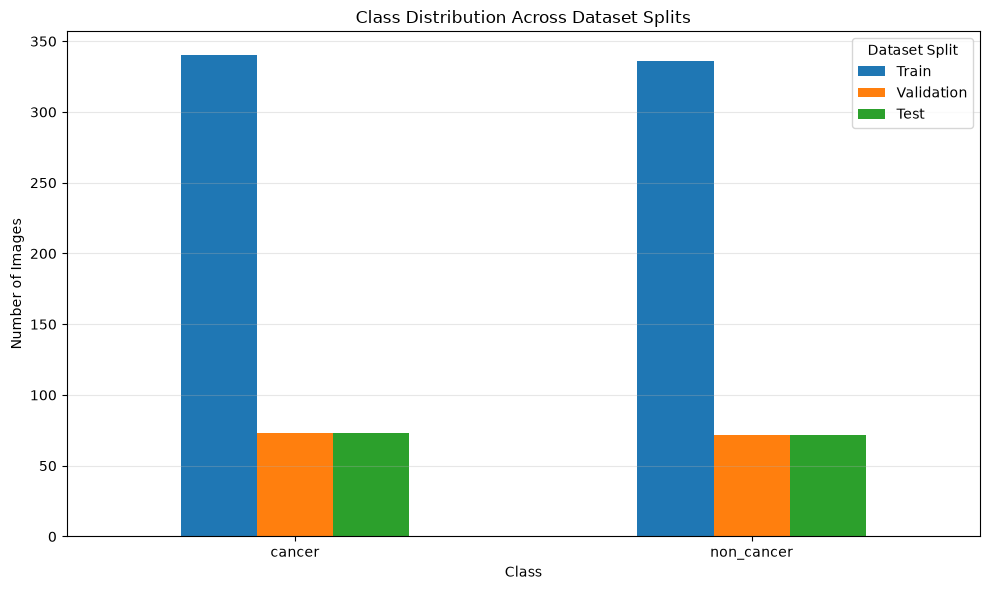

Stored 'train_df' (DataFrame)
Stored 'val_df' (DataFrame)
Stored 'test_df' (DataFrame)

SUCCESS: train_df, val_df, and test_df have been stored.
CNN training has not started.


In [11]:
# ============================================================
# STEP: Clean Dataset and Split into Train / Validation / Test
# ============================================================

import os
import hashlib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tqdm import tqdm

# ------------------------------------------------------------
# 1. Retrieve previously stored image paths
# ------------------------------------------------------------

try:
    %store -r cancer_image_files
    %store -r non_cancer_image_files
except Exception as e:
    print("Error retrieving stored image lists:", e)

# Check whether the variables exist
if "cancer_image_files" not in globals() or "non_cancer_image_files" not in globals():
    raise ValueError(
        "Image lists are not available. Please run the cell that collects "
        "cancer_image_files and non_cancer_image_files first."
    )

print("Cancer images found:", len(cancer_image_files))
print("Non-cancer images found:", len(non_cancer_image_files))

# ------------------------------------------------------------
# 2. Combine image paths and labels
# ------------------------------------------------------------

all_image_paths = []
labels = []

for image_path in cancer_image_files:
    if os.path.isfile(image_path):
        all_image_paths.append(image_path)
        labels.append("cancer")

for image_path in non_cancer_image_files:
    if os.path.isfile(image_path):
        all_image_paths.append(image_path)
        labels.append("non_cancer")

dataset_df = pd.DataFrame({
    "image_path": all_image_paths,
    "label": labels
})

print("\nTotal valid images:", len(dataset_df))
print("\nOriginal class distribution:")
print(dataset_df["label"].value_counts())

# ------------------------------------------------------------
# 3. Remove exact duplicate images using file content hash
# ------------------------------------------------------------

print("\nChecking for exact duplicate images...")

def calculate_md5(image_path):
    try:
        with open(image_path, "rb") as file:
            return hashlib.md5(file.read()).hexdigest()
    except Exception:
        return None

dataset_df["file_hash"] = [
    calculate_md5(path)
    for path in tqdm(
        dataset_df["image_path"],
        desc="Calculating image hashes"
    )
]

before_duplicates = len(dataset_df)

# Keep the first copy of each exact image
dataset_df = dataset_df.drop_duplicates(
    subset="file_hash",
    keep="first"
).reset_index(drop=True)

removed_duplicates = before_duplicates - len(dataset_df)

print("Exact duplicate images removed:", removed_duplicates)
print("Images remaining:", len(dataset_df))

# Remove helper column
dataset_df = dataset_df.drop(columns=["file_hash"])

# ------------------------------------------------------------
# 4. First split: 70% train and 30% temporary
# ------------------------------------------------------------

train_df, temporary_df = train_test_split(
    dataset_df,
    test_size=0.30,
    random_state=42,
    stratify=dataset_df["label"]
)

# ------------------------------------------------------------
# 5. Second split: temporary into 15% validation and 15% test
# ------------------------------------------------------------

val_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    random_state=42,
    stratify=temporary_df["label"]
)

# Reset indexes
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# ------------------------------------------------------------
# 6. Verify split sizes
# ------------------------------------------------------------

print("\n========== SPLIT SUMMARY ==========")
print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))
print("Total images:", len(train_df) + len(val_df) + len(test_df))

print("\n========== CLASS DISTRIBUTION ==========")

distribution_table = pd.DataFrame({
    "Train": train_df["label"].value_counts(),
    "Validation": val_df["label"].value_counts(),
    "Test": test_df["label"].value_counts()
}).fillna(0).astype(int)

print(distribution_table)

# ------------------------------------------------------------
# 7. Verify that no image appears in more than one split
# ------------------------------------------------------------

train_paths = set(train_df["image_path"])
val_paths = set(val_df["image_path"])
test_paths = set(test_df["image_path"])

train_val_overlap = train_paths.intersection(val_paths)
train_test_overlap = train_paths.intersection(test_paths)
val_test_overlap = val_paths.intersection(test_paths)

print("\n========== OVERLAP CHECK ==========")
print("Train-Validation overlap:", len(train_val_overlap))
print("Train-Test overlap:", len(train_test_overlap))
print("Validation-Test overlap:", len(val_test_overlap))

if (
    len(train_val_overlap) == 0
    and len(train_test_overlap) == 0
    and len(val_test_overlap) == 0
):
    print("SUCCESS: No image appears in more than one split.")
else:
    raise ValueError("Data leakage detected between splits.")

# ------------------------------------------------------------
# 8. Plot class distribution
# ------------------------------------------------------------

distribution_table.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Class Distribution Across Dataset Splits")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.legend(title="Dataset Split")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. Save variables for future Colab cells
# ------------------------------------------------------------

%store train_df
%store val_df
%store test_df

print("\nSUCCESS: train_df, val_df, and test_df have been stored.")
print("CNN training has not started.")

**Step 3 ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â Preprocess the images**

## Image Preprocessing Pipeline

This section outlines the image preprocessing steps using `torchvision.transforms` for the oral cancer classification task. The goal is to prepare the image data for consumption by a Convolutional Neural Network (CNN), ensuring consistency and introducing data augmentation for the training set to improve model generalization.

In [12]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
from torch.utils.data import Dataset, DataLoader

# Define ImageNet mean and standard deviation for normalization
# These values are commonly used when working with pre-trained models on ImageNet.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print(f"ImageNet Mean: {IMAGENET_MEAN}")
print(f"ImageNet Standard Deviation: {IMAGENET_STD}")

ImageNet Mean: [0.485, 0.456, 0.406]
ImageNet Standard Deviation: [0.229, 0.224, 0.225]


### 1. Training Data Transformations

For the training set, we apply data augmentation techniques to introduce variability and help the model generalize better to unseen data. This reduces overfitting.

*   **`transforms.Resize((224, 224))`**: Resizes all images to a fixed size of 224x224 pixels. This is a standard input size for many pre-trained CNN architectures.
*   **`transforms.RandomHorizontalFlip()`**: Randomly flips the image horizontally with a default probability of 0.5. This helps the model learn that horizontal orientation does not affect the lesion's nature.
*   **`transforms.RandomRotation(10)`**: Randomly rotates the image by up to 10 degrees (clockwise or counter-clockwise). This helps the model become invariant to slight variations in image orientation.
*   **`transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1)`**: Randomly changes the brightness, contrast, and saturation of the images by a small factor (up to 10%). This makes the model more robust to varying lighting conditions and camera settings. The factors are kept small to avoid distorting clinically relevant features.
*   **`transforms.ToTensor()`**: Converts the PIL Image or numpy.ndarray to a PyTorch `FloatTensor` and scales the pixel intensity values from [0, 255] to [0.0, 1.0]. This is required for PyTorch models.
*   **`transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)`**: Normalizes the tensor image with the specified mean and standard deviation. This step is crucial when using pre-trained models (like those trained on ImageNet), as they expect inputs to be normalized in a similar way. It standardizes the input distribution, which often helps in faster convergence and better performance.

In [13]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1), # Mild color augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Training Transformations Defined:")
print(train_transform)

Training Transformations Defined:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=(0.9, 1.1), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


### 2. Validation and Test Data Transformations

For validation and test sets, we only apply transformations that ensure consistency without introducing randomness. This is because we want to evaluate the model's performance on a fixed, representative distribution of data.

*   **`transforms.Resize((224, 224))`**: Resizes all images to a fixed size of 224x224 pixels, consistent with the training data.
*   **`transforms.ToTensor()`**: Converts the PIL Image or numpy.ndarray to a PyTorch `FloatTensor` and scales the pixel intensity values from [0, 255] to [0.0, 1.0].
*   **`transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)`**: Normalizes the tensor image using the same ImageNet mean and standard deviation as the training set, maintaining consistency for the pre-trained model.

In [14]:
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Validation and Test Transformations Defined:")
print(val_test_transform)

Validation and Test Transformations Defined:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


### 3. Custom Dataset Class

To effectively use the transformations with PyTorch's `DataLoader`, we'll create a custom `Dataset` class. This class will handle loading images from their paths and applying the specified transformations.

In [15]:
class OralCancerDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        # Map string labels to numerical format for PyTorch
        self.label_map = {'cancer': 0, 'non_cancer': 1}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        label_str = self.dataframe.iloc[idx]['label']
        label = self.label_map[label_str] # Convert string label to integer

        try:
            image = Image.open(img_path).convert('RGB') # Ensure image is RGB
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return a black image or handle error appropriately
            image = Image.new('RGB', (224, 224)) # Return a dummy image
            label = -1 # Indicate an error or skip this sample in DataLoader

        if self.transform:
            image = self.transform(image)

        return image, label

print("OralCancerDataset class defined.")

OralCancerDataset class defined.


### 4. Display Sample Images Before and After Preprocessing

Let's visualize the effect of the transformations on a few sample images from the training set. This helps confirm that the transformations are applied as expected and don't introduce unintended artifacts.

Since `train_df`, `val_df`, and `test_df` are stored from the previous cell, we will retrieve them here.

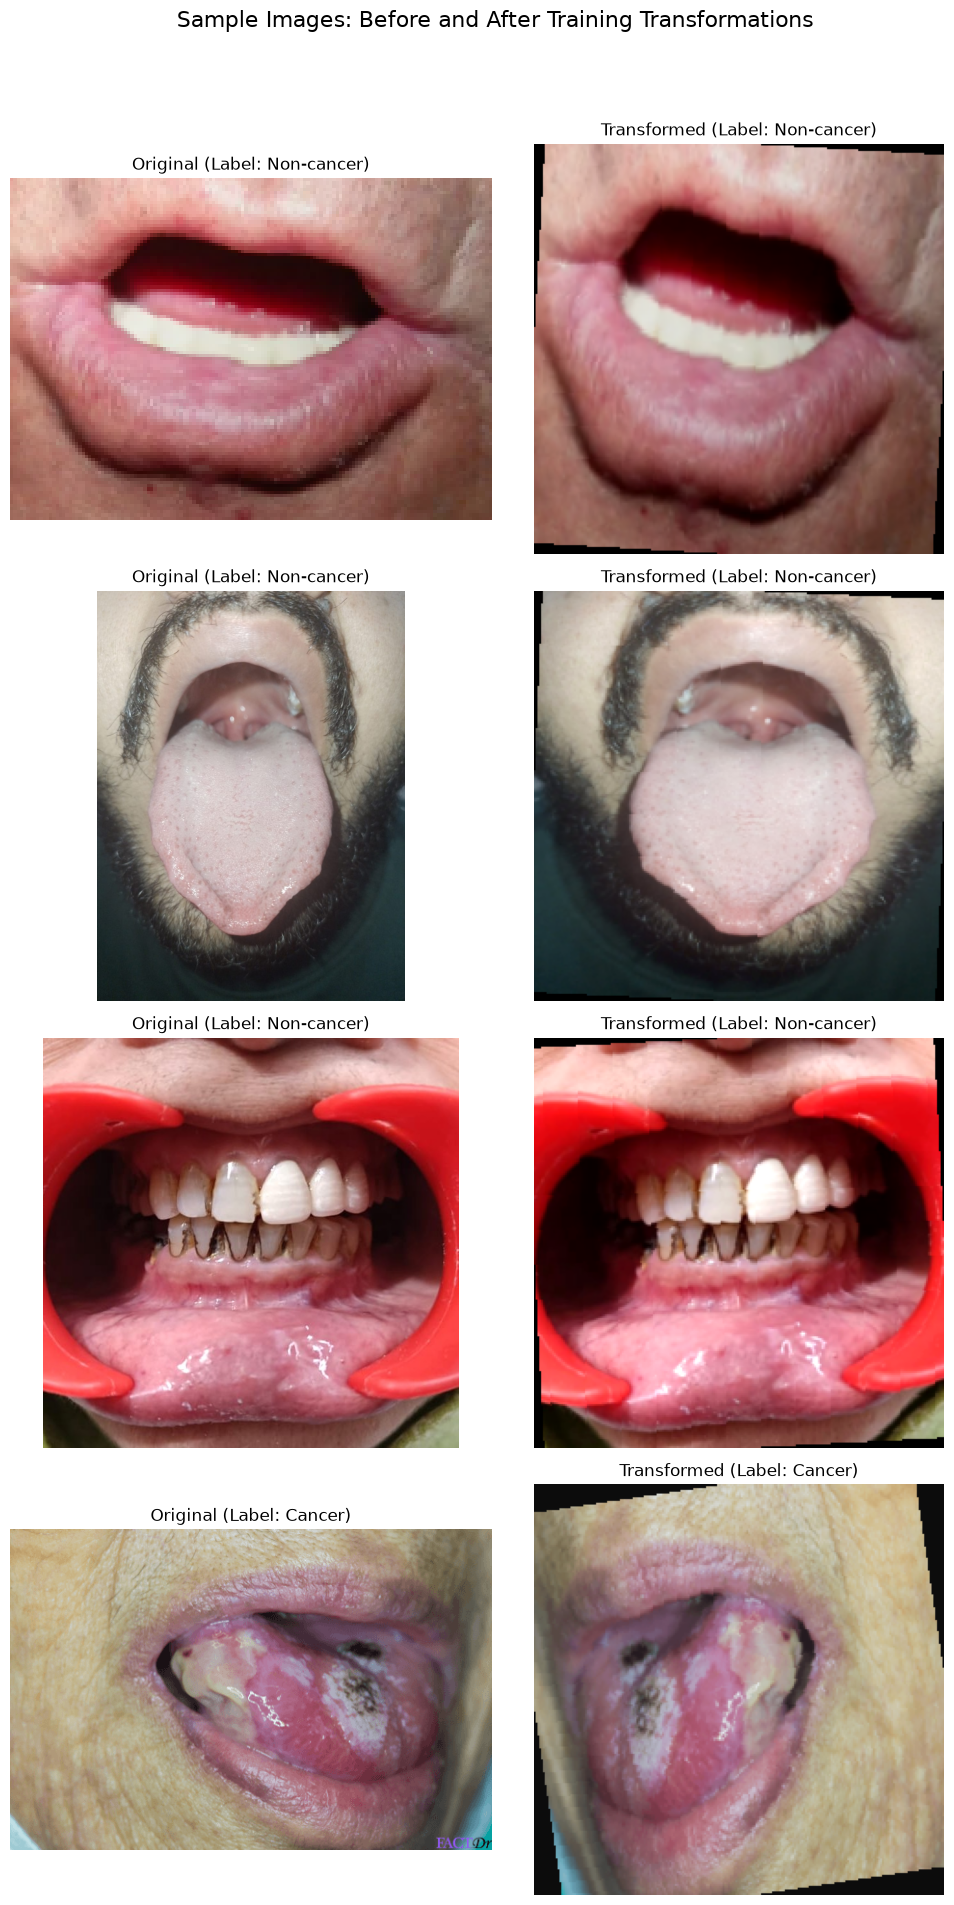

In [ ]:
# Retrieve stored dataframes
%store -r train_df
%store -r val_df
%store -r test_df

# Instantiate datasets
train_dataset_raw = OralCancerDataset(train_df, transform=None) # No transform for raw display
train_dataset_transformed = OralCancerDataset(train_df, transform=train_transform)

# Function to denormalize image for display
def denormalize(tensor, mean, std):
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m) # Denormalize
    return tensor

# Display some sample images
num_samples_to_display = 4

fig, axes = plt.subplots(num_samples_to_display, 2, figsize=(10, 5 * num_samples_to_display))
fig.suptitle('Sample Images: Before and After Training Transformations', fontsize=16)

for i in range(num_samples_to_display):
    # Get raw image (before transform)
    raw_image, raw_label = train_dataset_raw[i]

    # Convert label to string for display
    raw_label_str = 'Cancer' if raw_label == 0 else 'Non-cancer'

    axes[i, 0].imshow(raw_image)
    axes[i, 0].set_title(f"Original (Label: {raw_label_str})")
    axes[i, 0].axis('off')

    # Get transformed image
    transformed_image, transformed_label = train_dataset_transformed[i]

    # Convert label to string for display
    transformed_label_str = 'Cancer' if transformed_label == 0 else 'Non-cancer'

    # Denormalize for correct display
    display_image = denormalize(transformed_image.clone(), IMAGENET_MEAN, IMAGENET_STD)
    axes[i, 1].imshow(display_image.permute(1, 2, 0)) # Change from (C, H, W) to (H, W, C)
    axes[i, 1].set_title(f"Transformed (Label: {transformed_label_str})")
    axes[i, 1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Step 4-Build the PyTorch Dataset and DataLoaders**

In [ ]:
# ============================================================
# STEP: Create PyTorch Datasets and DataLoaders
# ============================================================

import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torchvision # Import torchvision here

# Retrieve previously stored dataframes, transforms, and constants
# These were generated in earlier steps of the notebook.
try:
    %store -r train_df
    %store -r val_df
    %store -r test_df
    %store -r train_transform
    %store -r val_test_transform
    %store -r IMAGENET_MEAN
    %store -r IMAGENET_STD
except Exception as e:
    print(f"Error retrieving stored variables: {e}")
    print("Please ensure previous cells defining these variables have been run.")

# Ensure the OralCancerDataset class is defined. It should have been defined in a previous cell.
# If this cell is run independently, you might need to re-run the cell where OralCancerDataset is defined.
if 'OralCancerDataset' not in globals():
    raise NameError("OralCancerDataset class not found. Please run the cell where it is defined.")

print("Stored dataframes and transforms retrieved successfully.")

# 1. Instantiate Datasets for each split
# The OralCancerDataset class handles loading images and applying transformations.
# The `transform` argument will apply the defined preprocessing steps.

train_dataset = OralCancerDataset(train_df, transform=train_transform)
val_dataset = OralCancerDataset(val_df, transform=val_test_transform)
test_dataset = OralCancerDataset(test_df, transform=val_test_transform)

print(f"\nTrain Dataset size: {len(train_dataset)} samples")
print(f"Validation Dataset size: {len(val_dataset)} samples")
print(f"Test Dataset size: {len(test_dataset)} samples")

# 2. Print the class-to-index mapping
# This mapping is defined within the OralCancerDataset class for converting labels to numerical format.
# We need to create an inverse map for displaying labels in the imshow function.
train_dataset.label_map_inv = {v: k for k, v in train_dataset.label_map.items()}
print("\nClass-to-index mapping:", train_dataset.label_map)

# 3. Create DataLoaders
BATCH_SIZE = 32 # A common batch size, adjust based on GPU memory
NUM_WORKERS = 2 # Number of subprocesses to use for data loading (good for Colab)

# DataLoaders are responsible for iterating over the dataset in batches.
# shuffle=True for training data ensures random order, aiding generalization.
# shuffle=False for validation/test data ensures consistent evaluation order.

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True # Speeds up data transfer to GPU
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("\nDataLoaders created successfully:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Number of workers: {NUM_WORKERS}")

# 4. Display one batch shape and label shape, and verify loading
print("\nVerifying a batch from the training loader...")

# Get one batch of training data
# iter() creates an iterator from the DataLoader
# next() gets the next item from the iterator (which is a batch)
images, labels = next(iter(train_loader))

print(f"  Batch image tensor shape: {images.shape} (Batch Size, Channels, Height, Width)")
print(f"  Batch label tensor shape: {labels.shape} (Batch Size)")
print(f"  Sample labels: {labels[:5].tolist()}") # Display first 5 labels

# Verify that images and labels are loaded correctly by visualizing a few
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0)) # Convert from (C, H, W) to (H, W, C)
    mean = np.array(IMAGENET_MEAN)
    std = np.array(IMAGENET_STD)
    inp = std * inp + mean # Denormalize
    inp = np.clip(inp, 0, 1) # Clip values to [0, 1] for display
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')

# Make a grid from batch
out = torchvision.utils.make_grid(images[:4]) # Take first 4 images for display

plt.figure(figsize=(10, 5))
# Use the inverse label map for displaying titles correctly
plt.imshow(out.cpu().numpy().transpose((1, 2, 0)))
plt.title("Sample Batch Images and Labels (Training Data)")
plt.xticks([])
plt.yticks([])
plt.show()

print("\nSUCCESS: PyTorch Datasets and DataLoaders created and verified.")

# 5. Handling corrupted images
# The `OralCancerDataset.__getitem__` method includes a try-except block
# that returns a dummy image and a label of -1 if an image file cannot be opened.
# This prevents the DataLoader from crashing.
# If you wish to explicitly remove corrupted images from your dataframes,
# you would perform an additional check before creating the datasets, for example:
# filtered_train_df = train_df[train_df['image_path'].apply(lambda p: os.path.exists(p) and Image.open(p).verify() is None)]
# However, the initial data loading and cleaning steps have already performed file existence
# and basic integrity checks, so the presence of truly corrupted images in the DataFrames
# at this stage should be minimal or non-existent.
# For models, samples with label -1 would need to be filtered out during training or
# have their loss set to zero, but preemptive removal is generally preferred.
# Given previous checks, we expect the dataframes to be clean.

no stored variable or alias train_transform
no stored variable or alias val_test_transform
no stored variable or alias IMAGENET_MEAN
no stored variable or alias IMAGENET_STD
Stored dataframes and transforms retrieved successfully.

Train Dataset size: 676 samples
Validation Dataset size: 145 samples
Test Dataset size: 145 samples

Class-to-index mapping: {'cancer': 0, 'non_cancer': 1}

DataLoaders created successfully:
  Batch size: 32
  Number of workers: 2

Verifying a batch from the training loader...


c:\Users\Admin\OneDrive\Desktop\Oral_Cancer\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


**Step 5-Build the CNN model**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# 1. Device configuration (Move model to GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Load pretrained ResNet18 with ImageNet weights
# ResNet18 is a popular choice for transfer learning due to its balance of depth and computational efficiency.
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 3. Replace the final fully connected layer for binary classification
# The original ResNet18 'fc' layer is designed for 1000 ImageNet classes.
# We need to replace it with a new layer that outputs 2 classes (cancer/non-cancer).
num_ftrs = model.fc.in_features # Get the number of input features to the original fc layer
num_classes = 2 # Binary classification: cancer and non_cancer
model.fc = nn.Linear(num_ftrs, num_classes) # Replace the layer

# Move the model to the configured device
model = model.to(device)

# 4. Print the model architecture
print("\n--- Model Architecture ---")
print(model)

# 5. Print the total number of trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

# 6. Define Loss Function and Optimizer
# For binary classification with integer labels (0 or 1) and two output classes,
# CrossEntropyLoss is suitable. It combines LogSoftmax and NLLLoss in one,
# making it robust for multi-class (including binary) problems. It expects raw logits.
# BCEWithLogitsLoss is also excellent for binary classification, especially when dealing
# with multi-label problems or when you want explicit control over sigmoid activation.
# However, for simple binary classification with two distinct classes and integer labels,
# CrossEntropyLoss is a common and appropriate choice.

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4) # Learning rate 1e-4 as requested

print("\nLoss Function: CrossEntropyLoss (suitable for 2 output classes with integer labels)")
print(f"Optimizer: Adam with learning rate {optimizer.defaults['lr']}")

# 7. Explanation of Transfer Learning
print("\n--- Explanation of Transfer Learning ---")
print("Transfer learning is a machine learning technique where a model trained on one task")
print("is re-purposed for a second related task. Instead of training a deep learning model")
print("from scratch, which requires a vast amount of data and computational resources,")
print("we start with a pre-trained model (like ResNet18 trained on ImageNet).")
print("This pre-trained model has already learned general features (edges, textures, shapes)")
print("from a large dataset. For our specific task (oral cancer classification),")
print("we leverage these learned features and usually replace or fine-tune the final layers")
print("of the network to adapt it to our smaller, specific dataset. This approach often")
print("leads to faster convergence and better performance, especially when the target")
print("dataset is smaller than the original training dataset.")

print("\nModel setup complete. The model is ready for training (but not yet trained).")

**Step 6 ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â Train the CNN**

In [ ]:
# ============================================================
# RESNET18 TRAINING - ORAL CANCER BINARY CLASSIFICATION
# ============================================================

import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# 2. Select device
# ------------------------------------------------------------

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

# ------------------------------------------------------------
# 3. Move model to device
# ------------------------------------------------------------

model = model.to(device)

# ------------------------------------------------------------
# 4. Loss function and optimizer
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

# ------------------------------------------------------------
# 5. Training settings
# ------------------------------------------------------------

num_epochs = 20
patience = 5

best_val_loss = float("inf")
epochs_without_improvement = 0

# Store results
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

# Path to save best model
best_model_path = "best_oral_cancer_resnet18.pth"

# ------------------------------------------------------------
# 6. Training loop
# ------------------------------------------------------------

for epoch in range(num_epochs):

    # ========================================================
    # TRAINING
    # ========================================================

    model.train()

    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    train_progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{num_epochs} - Training",
        leave=False
    )

    for images, labels in train_progress:

        # Move data to GPU/CPU
        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        # Track loss
        running_train_loss += loss.item() * images.size(0)

        # Calculate predictions
        predictions = torch.argmax(outputs, dim=1)

        correct_train += (predictions == labels).sum().item()
        total_train += labels.size(0)

        # Update progress bar
        train_progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    # Average training loss and accuracy
    epoch_train_loss = running_train_loss / total_train
    epoch_train_accuracy = correct_train / total_train

    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        val_progress = tqdm(
            val_loader,
            desc=f"Epoch {epoch + 1}/{num_epochs} - Validation",
            leave=False
        )

        for images, labels in val_progress:

            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Validation loss
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            # Predictions
            predictions = torch.argmax(outputs, dim=1)

            correct_val += (predictions == labels).sum().item()
            total_val += labels.size(0)

    # Average validation loss and accuracy
    epoch_val_loss = running_val_loss / total_val
    epoch_val_accuracy = correct_val / total_val

    # --------------------------------------------------------
    # Store metrics
    # --------------------------------------------------------

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    train_accuracies.append(epoch_train_accuracy)
    val_accuracies.append(epoch_val_accuracy)

    # --------------------------------------------------------
    # Print epoch results
    # --------------------------------------------------------

    print(
        f"Epoch [{epoch + 1:02d}/{num_epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_accuracy:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_accuracy:.4f}"
    )

    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss
        epochs_without_improvement = 0

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print("  ÃƒÆ’Ã‚Â¢Ãƒâ€¦Ã¢â‚¬Å“ÃƒÂ¢Ã¢â€šÂ¬Ã…â€œ Best model saved!")

    else:

        epochs_without_improvement += 1

        print(
            f"  No improvement "
            f"({epochs_without_improvement}/{patience})"
        )

    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if epochs_without_improvement >= patience:

        print("\nEarly stopping triggered.")
        print(
            f"Validation loss did not improve for "
            f"{patience} consecutive epochs."
        )

        break

# ============================================================
# 7. Training completed
# ============================================================

print("\n" + "=" * 60)
print("TRAINING COMPLETED")
print("=" * 60)

print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best model saved at: {best_model_path}")

# ============================================================
# 8. Plot loss curves
# ============================================================

epochs_completed = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_completed,
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_completed,
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 9. Plot accuracy curves
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_completed,
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_completed,
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

**Step 7 ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â Evaluate the model properly**

In [ ]:
# ============================================================
# RESNET18 BINARY ORAL CANCER CLASSIFICATION
# HELD-OUT TEST SET EVALUATION
# ============================================================

import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# ------------------------------------------------------------
# 1. Reproducibility and device
# ------------------------------------------------------------

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


# ------------------------------------------------------------
# 2. Define the ResNet18 model
# ------------------------------------------------------------

model = models.resnet18(weights=None)

num_features = model.fc.in_features

# Binary classification:
# class 0 = Cancer
# class 1 = Non-cancer
model.fc = nn.Linear(num_features, 2)

model = model.to(device)


# ------------------------------------------------------------
# 3. Load the BEST saved model
# ------------------------------------------------------------

best_model_path = "best_oral_cancer_resnet18.pth"

if not os.path.exists(best_model_path):
    raise FileNotFoundError(
        f"Could not find {best_model_path}. "
        "Make sure the best model was saved during training."
    )

model.load_state_dict(
    torch.load(best_model_path, map_location=device)
)

model.eval()

print("\nBest ResNet18 model loaded successfully.")
print("Model:", best_model_path)


# ------------------------------------------------------------
# 4. Class names
# ------------------------------------------------------------

# IMPORTANT:
# These indices must match your Dataset mapping.
#
# Earlier we used:
# cancer     -> 0
# non_cancer -> 1

class_names = ["Cancer", "Non-cancer"]

print("\nClass mapping:")
print("0 =", class_names[0])
print("1 =", class_names[1])


# ------------------------------------------------------------
# 5. Evaluate ONLY on the test dataset
# ------------------------------------------------------------

all_true_labels = []
all_pred_labels = []
all_cancer_probabilities = []

total_test_images = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Convert logits to probabilities
        probabilities = torch.softmax(outputs, dim=1)

        # Predicted class
        predictions = torch.argmax(probabilities, dim=1)

        # Probability of Cancer class
        cancer_probabilities = probabilities[:, 0]

        # Store results
        all_true_labels.extend(labels.cpu().numpy())
        all_pred_labels.extend(predictions.cpu().numpy())
        all_cancer_probabilities.extend(
            cancer_probabilities.cpu().numpy()
        )

        total_test_images += labels.size(0)


# Convert to NumPy arrays
y_true = np.array(all_true_labels)
y_pred = np.array(all_pred_labels)
y_prob = np.array(all_cancer_probabilities)

print("\nTest evaluation completed.")
print("Total test images:", total_test_images)


# ------------------------------------------------------------
# 6. Calculate overall metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    pos_label=0,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    pos_label=0,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    pos_label=0,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_true,
    y_prob
)


# ------------------------------------------------------------
# 7. Calculate confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

tp, fn, fp, tn = cm.ravel()

# Specificity = TN / (TN + FP)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0


# ------------------------------------------------------------
# 8. Print overall results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("RESNET18 TEST SET RESULTS")
print("=" * 60)

print(f"Accuracy     : {accuracy:.4f}  ({accuracy * 100:.2f}%)")
print(f"Precision    : {precision:.4f}  ({precision * 100:.2f}%)")
print(f"Recall       : {recall:.4f}  ({recall * 100:.2f}%)")
print(f"Sensitivity  : {recall:.4f}  ({recall * 100:.2f}%)")
print(f"Specificity  : {specificity:.4f}  ({specificity * 100:.2f}%)")
print(f"F1-score     : {f1:.4f}")
print(f"ROC-AUC      : {roc_auc:.4f}")

print("=" * 60)


# ------------------------------------------------------------
# 9. Print confusion matrix values
# ------------------------------------------------------------

print("\nConfusion Matrix Values:")
print("--------------------------------")
print(f"True Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives  (TP): {tp}")


# ------------------------------------------------------------
# 10. Display confusion matrix
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet18 - Test Set Confusion Matrix")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. Classification report
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

report = classification_report(
    y_true,
    y_pred,
    labels=[0, 1],
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)


# ------------------------------------------------------------
# 12. ROC Curve
# ------------------------------------------------------------

fpr, tpr, thresholds = roc_curve(
    y_true,
    y_prob,
    pos_label=0
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ResNet18 (AUC = {roc_auc:.4f})",
    linewidth=2
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensitivity")
plt.title("ResNet18 ROC Curve - Held-out Test Set")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 13. Per-class metrics
# ------------------------------------------------------------

precision_per_class = precision_score(
    y_true,
    y_pred,
    labels=[0, 1],
    average=None,
    zero_division=0
)

recall_per_class = recall_score(
    y_true,
    y_pred,
    labels=[0, 1],
    average=None,
    zero_division=0
)

f1_per_class = f1_score(
    y_true,
    y_pred,
    labels=[0, 1],
    average=None,
    zero_division=0
)

print("\n" + "=" * 60)
print("PER-CLASS METRICS")
print("=" * 60)

for i, class_name in enumerate(class_names):

    print(f"\n{class_name}")
    print("-" * 30)
    print(f"Precision : {precision_per_class[i]:.4f}")
    print(f"Recall    : {recall_per_class[i]:.4f}")
    print(f"F1-score  : {f1_per_class[i]:.4f}")


# ------------------------------------------------------------
# 14. Calculate class-specific sensitivity/specificity
# ------------------------------------------------------------

# For CANCER as the positive class:
# TN = TP from Cancer perspective
# FP = FN from Cancer perspective
# FN = FP from Cancer perspective
# TP = TN from Cancer perspective

non_cancer_sensitivity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

non_cancer_specificity = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else 0.0
)

print("\n" + "=" * 60)
print("CLASS-SPECIFIC SENSITIVITY / SPECIFICITY")
print("=" * 60)

print(f"\nCancer:")
print(f"Sensitivity : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")

print(f"\nNon-cancer:")
print(f"Sensitivity : {non_cancer_sensitivity:.4f}")
print(f"Specificity : {non_cancer_specificity:.4f}")


# ------------------------------------------------------------
# 15. Explain false positives and false negatives
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("ERROR ANALYSIS")
print("=" * 60)

print(f"""
False Positives (FP): {fp}

A false positive occurs when an image that is actually
NON-CANCER is incorrectly predicted as CANCER.

In a screening context, false positives can result in:
- unnecessary clinical concern
- additional examinations
- unnecessary biopsies or referrals
- increased healthcare costs


False Negatives (FN): {fn}

A false negative occurs when an image that is actually
CANCER is incorrectly predicted as NON-CANCER.

False negatives are particularly important in cancer
screening because a potentially cancerous lesion may be
missed or its diagnosis may be delayed.

Therefore, sensitivity/recall for the CANCER class is
especially important when evaluating a screening-oriented
model.
""")


# ------------------------------------------------------------
# 16. Sanity checks
# ------------------------------------------------------------

print("=" * 60)
print("SANITY CHECKS")
print("=" * 60)

print("Number of true labels       :", len(y_true))
print("Number of predictions      :", len(y_pred))
print("Number of probabilities    :", len(y_prob))

print("\nPrediction class counts:")

unique_pred, counts_pred = np.unique(
    y_pred,
    return_counts=True
)

for label, count in zip(unique_pred, counts_pred):
    print(f"{class_names[label]}: {count}")

print("\nTrue class counts:")

unique_true, counts_true = np.unique(
    y_true,
    return_counts=True
)

for label, count in zip(unique_true, counts_true):
    print(f"{class_names[label]}: {count}")


# ------------------------------------------------------------
# 17. Final interpretation reminder
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)

print("""
These results represent performance on the held-out test
dataset only.

Accuracy alone should NOT be used to claim that the model
is clinically reliable.

For an oral cancer classification model, attention should
also be given to:

- Cancer sensitivity/recall
- Specificity
- Precision
- F1-score
- ROC-AUC
- Confusion matrix
- Number of false negatives
- Number of false positives

Clinical reliability would require substantially more
validation, including appropriate independent datasets,
patient-level separation, representative populations,
and ultimately clinical validation.
""")

**Step 8 ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â Add Grad-CAM explainability**

In [ ]:
# ============================================================
# RESNET18 GRAD-CAM EXPLAINABILITY
# BOTH CORRECT AND INCORRECT PREDICTIONS
# ============================================================

# Install library inside this cell
!pip install -q grad-cam

# ------------------------------------------------------------
# IMPORTS
# ------------------------------------------------------------

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import models, transforms

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


# ------------------------------------------------------------
# 1. DEVICE
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ------------------------------------------------------------
# 2. RECREATE RESNET18
# ------------------------------------------------------------

model = models.resnet18(weights=None)

num_features = model.fc.in_features

# Class mapping:
# 0 = Cancer
# 1 = Non-cancer

model.fc = nn.Linear(
    num_features,
    2
)

model = model.to(device)


# ------------------------------------------------------------
# 3. LOAD BEST MODEL
# ------------------------------------------------------------

best_model_path = "best_oral_cancer_resnet18.pth"

if not os.path.exists(best_model_path):

    raise FileNotFoundError(
        f"Model not found: {best_model_path}"
    )

model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

model.eval()

print("Best ResNet18 loaded successfully.")


# ------------------------------------------------------------
# 4. CLASS NAMES
# ------------------------------------------------------------

class_names = [
    "Cancer",
    "Non-cancer"
]


# ------------------------------------------------------------
# 5. SAME PREPROCESSING USED FOR TESTING
# ------------------------------------------------------------

IMAGE_SIZE = 224

eval_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ------------------------------------------------------------
# 6. GRAD-CAM TARGET LAYER
# ------------------------------------------------------------

# Final convolutional layer of ResNet18

target_layers = [
    model.layer4[-1].conv2
]

print("\nGrad-CAM target layer:")
print(target_layers[0])


# ------------------------------------------------------------
# 7. CHECK TEST DATA
# ------------------------------------------------------------

if "test_df" not in globals():

    raise NameError(
        "test_df is not available. "
        "Run your dataset split cell first."
    )

print("\nNumber of test images:", len(test_df))


# ------------------------------------------------------------
# 8. GENERATE TEST PREDICTIONS
# ------------------------------------------------------------

results = []

model.eval()

for _, row in test_df.iterrows():

    image_path = row["image_path"]

    # Actual label
    actual_label = (
        0 if row["label"] == "cancer"
        else 1
    )

    try:

        image = Image.open(
            image_path
        ).convert("RGB")

        input_tensor = eval_transform(
            image
        ).unsqueeze(0).to(device)

        # Prediction
        with torch.no_grad():

            outputs = model(
                input_tensor
            )

            probabilities = torch.softmax(
                outputs,
                dim=0
            )

            predicted_label = torch.argmax(
                probabilities,
                dim=0
            ).item()

            predicted_probability = probabilities[
                0,
                predicted_label
            ].item()

            cancer_probability = probabilities[
                0,
                0
            ].item()

        results.append({

            "image_path": image_path,

            "actual": actual_label,

            "predicted": predicted_label,

            "predicted_probability":
                predicted_probability,

            "cancer_probability":
                cancer_probability
        })

    except Exception as e:

        print(
            f"Could not process {image_path}: {e}"
        )


# Convert to DataFrame

results_df = pd.DataFrame(
    results
)

print(
    "\nPredictions generated:",
    len(results_df)
)


# ------------------------------------------------------------
# 9. CREATE FOUR PREDICTION GROUPS
# ------------------------------------------------------------

# Correct Cancer
correct_cancer = results_df[
    (results_df["actual"] == 0) &
    (results_df["predicted"] == 0)
]


# False Negative
# Actual Cancer -> Predicted Non-cancer

false_negative = results_df[
    (results_df["actual"] == 0) &
    (results_df["predicted"] == 1)
]


# Correct Non-cancer
correct_non_cancer = results_df[
    (results_df["actual"] == 1) &
    (results_df["predicted"] == 1)
]


# False Positive
# Actual Non-cancer -> Predicted Cancer

false_positive = results_df[
    (results_df["actual"] == 1) &
    (results_df["predicted"] == 0)
]


# ------------------------------------------------------------
# 10. PRINT COUNTS
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("TEST PREDICTION CATEGORIES")
print("=" * 65)

print(
    f"Correct Cancer       : {len(correct_cancer)}"
)

print(
    f"False Negatives      : {len(false_negative)}"
)

print(
    f"Correct Non-cancer   : {len(correct_non_cancer)}"
)

print(
    f"False Positives      : {len(false_positive)}"
)


# ------------------------------------------------------------
# 11. GRAD-CAM FUNCTION
# ------------------------------------------------------------

def generate_gradcam(
    image_path,
    predicted_class
):

    # Load image

    image = Image.open(
        image_path
    ).convert("RGB")

    # Resize to model input size

    display_image = image.resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    )

    # Convert to numpy [0,1]

    rgb_image = np.array(
        display_image
    ).astype(
        np.float32
    ) / 255.0

    # Apply SAME preprocessing

    input_tensor = eval_transform(
        image
    ).unsqueeze(0).to(device)

    # Grad-CAM target

    targets = [
        ClassifierOutputTarget(
            predicted_class
        )
    ]

    # Generate Grad-CAM

    with GradCAM(
        model=model,
        target_layers=target_layers
    ) as cam:

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=targets
        )[0]

    # Create overlay

    overlay = show_cam_on_image(
        rgb_image,
        grayscale_cam,
        use_rgb=True
    )

    return (
        rgb_image,
        grayscale_cam,
        overlay
    )


# ------------------------------------------------------------
# 12. DISPLAY ONE GRAD-CAM RESULT
# ------------------------------------------------------------

def display_result(row, category):

    image_path = row["image_path"]

    actual_class = int(
        row["actual"]
    )

    predicted_class = int(
        row["predicted"]
    )

    predicted_probability = float(
        row["predicted_probability"]
    )

    cancer_probability = float(
        row["cancer_probability"]
    )

    # Generate Grad-CAM

    original, heatmap, overlay = generate_gradcam(
        image_path,
        predicted_class
    )

    actual_name = class_names[
        actual_class
    ]

    predicted_name = class_names[
        predicted_class
    ]

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(16, 5)
    )

    # Original

    axes[0].imshow(
        original
    )

    axes[0].set_title(
        "Original Image"
    )

    axes[0].axis("off")


    # Heatmap

    axes[1].imshow(
        heatmap,
        cmap="jet"
    )

    axes[1].set_title(
        "Grad-CAM Heatmap"
    )

    axes[1].axis("off")


    # Overlay

    axes[2].imshow(
        overlay
    )

    axes[2].set_title(
        "Grad-CAM Overlay"
    )

    axes[2].axis("off")


    # --------------------------------------------------------
    # Overall title
    # --------------------------------------------------------

    plt.suptitle(
        f"{category}\n"
        f"Actual: {actual_name} | "
        f"Predicted: {predicted_name} | "
        f"Predicted Probability: "
        f"{predicted_probability:.2%}",
        fontsize=14
    )

    plt.tight_layout()

    plt.show()


    # --------------------------------------------------------
    # Detailed information
    # --------------------------------------------------------

    print(
        "Image:",
        image_path
    )

    print(
        "Actual class:",
        actual_name
    )

    print(
        "Predicted class:",
        predicted_name
    )

    print(
        f"Predicted-class probability: "
        f"{predicted_probability:.4f}"
    )

    print(
        f"Cancer probability: "
        f"{cancer_probability:.4f}"
    )


# ------------------------------------------------------------
# 13. FUNCTION TO SHOW MULTIPLE EXAMPLES
# ------------------------------------------------------------

def show_examples(
    dataframe,
    category,
    n=3
):

    print("\n")
    print("=" * 70)
    print(category)
    print("=" * 70)

    if len(dataframe) == 0:

        print(
            "No examples available in this category."
        )

        return

    examples = dataframe.head(n)

    for _, row in examples.iterrows():

        display_result(
            row,
            category
        )


# ============================================================
# 14. SHOW CORRECT CANCER EXAMPLES
# ============================================================

show_examples(
    correct_cancer,
    "CORRECT CANCER PREDICTIONS",
    n=3
)


# ============================================================
# 15. SHOW FALSE NEGATIVE EXAMPLES
# ============================================================

show_examples(
    false_negative,
    "FALSE NEGATIVES: ACTUAL CANCER ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ PREDICTED NON-CANCER",
    n=3
)


# ============================================================
# 16. SHOW CORRECT NON-CANCER EXAMPLES
# ============================================================

show_examples(
    correct_non_cancer,
    "CORRECT NON-CANCER PREDICTIONS",
    n=3
)


# ============================================================
# 17. SHOW FALSE POSITIVE EXAMPLES
# ============================================================

show_examples(
    false_positive,
    "FALSE POSITIVES: ACTUAL NON-CANCER ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ PREDICTED CANCER",
    n=3
)


# ============================================================
# 18. OPTIONAL: RANDOM EXAMPLES FROM BOTH ACTUAL CLASSES
# ============================================================

print("\n")
print("=" * 70)
print("ADDITIONAL REPRESENTATIVE TEST EXAMPLES")
print("=" * 70)

# Cancer examples regardless of prediction
cancer_examples = results_df[
    results_df["actual"] == 1
].sample(
    n=min(3, len(results_df[results_df["actual"] == 1])),
    random_state=42
)

# Non-cancer examples regardless of prediction
non_cancer_examples = results_df[
    results_df["actual"] == 0
].sample(
    n=min(3, len(results_df[results_df["actual"] == 0])),
    random_state=42
)


for _, row in cancer_examples.iterrows():

    display_result(
        row,
        "REPRESENTATIVE CANCER TEST IMAGE"
    )


for _, row in non_cancer_examples.iterrows():

    display_result(
        row,
        "REPRESENTATIVE NON-CANCER TEST IMAGE"
    )


# ============================================================
# 19. EXPLANATION
# ============================================================

print("\n")
print("=" * 70)
print("GRAD-CAM INTERPRETATION")
print("=" * 70)

print("""
Grad-CAM (Gradient-weighted Class Activation Mapping)
provides a visual explanation of the ResNet18 prediction.

The four important prediction categories are:

1. CORRECT CANCER
   Actual = Cancer
   Predicted = Cancer

2. FALSE NEGATIVE
   Actual = Cancer
   Predicted = Non-cancer

3. CORRECT NON-CANCER
   Actual = Non-cancer
   Predicted = Non-cancer

4. FALSE POSITIVE
   Actual = Non-cancer
   Predicted = Cancer

For each image, Grad-CAM shows:

- Original image
- Grad-CAM heatmap
- Heatmap overlaid on the original image

The highlighted regions indicate areas that contributed
more strongly to the model's prediction.

IMPORTANT:
Grad-CAM highlights model-relevant image regions. It does
NOT prove that those regions are medically confirmed
cancerous regions.

Therefore, Grad-CAM should be interpreted as an
explainability tool for understanding model behavior,
not as a clinical diagnostic tool.
""")

**Step 9 ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â Save the model and create a prediction function**

In [ ]:
# ============================================================
# RESNET18 ORAL CANCER - INFERENCE + GRAD-CAM
# ============================================================

# Install Grad-CAM inside this cell
!pip install -q grad-cam


# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import models, transforms

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


# ------------------------------------------------------------
# 2. DEVICE
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


# ------------------------------------------------------------
# 3. CLASS MAPPING
# ------------------------------------------------------------

# Must match the mapping used during training
# 0 = Cancer
# 1 = Non-cancer

class_names = [
    "Cancer",
    "Non-cancer"
]


# ------------------------------------------------------------
# 4. CREATE RESNET18
# ------------------------------------------------------------

model = models.resnet18(weights=None)

num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    2
)

model = model.to(device)


# ------------------------------------------------------------
# 5. LOAD BEST TRAINED MODEL
# ------------------------------------------------------------

best_model_path = "best_oral_cancer_resnet18.pth"

if not os.path.exists(best_model_path):
    raise FileNotFoundError(
        f"Could not find: {best_model_path}"
    )

model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

model.eval()

print("\nBest ResNet18 model loaded successfully.")
print("Model file:", best_model_path)


# ------------------------------------------------------------
# 6. SAVE TRAINED MODEL COPY
# ------------------------------------------------------------

saved_model_path = "oral_cancer_resnet18_trained.pth"

torch.save(
    model.state_dict(),
    saved_model_path
)

print(
    "Trained model saved as:",
    saved_model_path
)


# ------------------------------------------------------------
# 7. SAME VALIDATION/TEST PREPROCESSING
# ------------------------------------------------------------

IMAGE_SIZE = 224

eval_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ------------------------------------------------------------
# 8. UPLOAD A NEW IMAGE
# ------------------------------------------------------------

from google.colab import files

print("\nPlease select a new oral image to classify.")

uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError(
        "No image was uploaded."
    )

# Get uploaded filename

uploaded_filename = list(
    uploaded.keys()
)[0]

image_path = os.path.join(
    "/content",
    uploaded_filename
)

print("\nUploaded image:")
print(image_path)


# ------------------------------------------------------------
# 9. CHECK IMAGE
# ------------------------------------------------------------

if not os.path.exists(image_path):

    raise FileNotFoundError(
        f"Image not found: {image_path}"
    )


# ------------------------------------------------------------
# 10. LOAD IMAGE
# ------------------------------------------------------------

image = Image.open(
    image_path
).convert("RGB")


# ------------------------------------------------------------
# 11. DISPLAY ORIGINAL IMAGE
# ------------------------------------------------------------

plt.figure(
    figsize=(6, 6)
)

plt.imshow(image)

plt.title(
    "Uploaded Oral Image"
)

plt.axis("off")

plt.show()


# ------------------------------------------------------------
# 12. PREPROCESS IMAGE
# ------------------------------------------------------------

input_tensor = eval_transform(
    image
)

# Add batch dimension
# [3,224,224] -> [1,3,224,224]

input_tensor = input_tensor.unsqueeze(
    0
)

input_tensor = input_tensor.to(
    device
)


# ------------------------------------------------------------
# 13. RUN MODEL INFERENCE
# ------------------------------------------------------------

model.eval()

with torch.no_grad():

    outputs = model(
        input_tensor
    )

    probabilities = torch.softmax(
        outputs,
        dim=1
    )

    predicted_class = torch.argmax(
        probabilities,
        dim=1
    ).item()


# ------------------------------------------------------------
# 14. GET PROBABILITIES
# ------------------------------------------------------------

non_cancer_probability = probabilities[
    0, 1
].item()

cancer_probability = probabilities[
    0, 0
].item()


# ------------------------------------------------------------
# 15. CONFIDENCE
# ------------------------------------------------------------

confidence = probabilities[
    0,
    predicted_class
].item()

predicted_name = class_names[
    predicted_class
]


# ------------------------------------------------------------
# 16. DISPLAY PREDICTION
# ------------------------------------------------------------

print("\n")
print("=" * 65)
print("RESNET18 ORAL CANCER PREDICTION")
print("=" * 65)

print(
    f"Predicted class       : {predicted_name}"
)

print(
    f"Cancer probability    : "
    f"{cancer_probability:.4f} "
    f"({cancer_probability:.2%})"
)

print(
    f"Non-cancer probability: "
    f"{non_cancer_probability:.4f} "
    f"({non_cancer_probability:.2%})"
)

print(
    f"Confidence             : "
    f"{confidence:.4f} "
    f"({confidence:.2%})"
)

print("=" * 65)


# ------------------------------------------------------------
# 17. GRAD-CAM OPTION
# ------------------------------------------------------------

show_gradcam = True

if show_gradcam:

    print("\nGenerating Grad-CAM...")


    # Final convolutional layer of ResNet18

    target_layers = [
        model.layer4[-1].conv2
    ]


    # Explain the predicted class

    targets = [
        ClassifierOutputTarget(
            predicted_class
        )
    ]


    # Resize original image for visualization

    display_image = image.resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    )


    # Convert image to [0,1]

    rgb_image = np.array(
        display_image
    ).astype(
        np.float32
    ) / 255.0


    # Generate Grad-CAM

    with GradCAM(
        model=model,
        target_layers=target_layers
    ) as cam:

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=targets
        )[0]


    # Create overlay

    cam_overlay = show_cam_on_image(
        rgb_image,
        grayscale_cam,
        use_rgb=True
    )


    # --------------------------------------------------------
    # DISPLAY GRAD-CAM
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(16, 5)
    )


    # Original

    axes[0].imshow(
        rgb_image
    )

    axes[0].set_title(
        "Original Image"
    )

    axes[0].axis("off")


    # Heatmap

    axes[1].imshow(
        grayscale_cam,
        cmap="jet"
    )

    axes[1].set_title(
        "Grad-CAM Heatmap"
    )

    axes[1].axis("off")


    # Overlay

    axes[2].imshow(
        cam_overlay
    )

    axes[2].set_title(
        "Grad-CAM Overlay"
    )

    axes[2].axis("off")


    plt.suptitle(
        f"Predicted: {predicted_name} | "
        f"Confidence: {confidence:.2%}",
        fontsize=14
    )

    plt.tight_layout()

    plt.show()


# ------------------------------------------------------------
# 18. FINAL RESULT
# ------------------------------------------------------------

result = {
    "image": uploaded_filename,
    "predicted_class": predicted_name,
    "cancer_probability": cancer_probability,
    "non_cancer_probability": non_cancer_probability,
    "confidence": confidence
}


print("\nFinal result:")
print(result)


# ------------------------------------------------------------
# 19. IMPORTANT MEDICAL INTERPRETATION
# ------------------------------------------------------------

print("\n")
print("=" * 65)
print("IMPORTANT INTERPRETATION")
print("=" * 65)

print("""
The Cancer and Non-cancer probabilities are model outputs
generated by the ResNet18 classifier.

They are NOT medically validated probabilities of disease.

For example, a Cancer probability of 95% means that the
model strongly favors the Cancer class based on patterns
learned from its training data. It does NOT mean that there
is a medically confirmed 95% chance that the patient has
cancer.

The confidence score is also a model confidence measure,
not clinical certainty.

Grad-CAM highlights image regions that contributed to the
model's prediction. These regions should NOT be interpreted
as medically confirmed cancerous regions.

This model is intended for research/experimental purposes
and should not replace professional clinical assessment,
diagnostic procedures, or histopathological examination.
""")

In [ ]:
import torch

print("Class mapping:")
print("0 = Cancer")
print("1 = Non-cancer")

verification_class_names = ["Cancer", "Non-cancer"]
verification_probabilities = torch.tensor([[0.75, 0.25]])
verification_predicted_class = torch.argmax(
    verification_probabilities,
    dim=1
).item()
verification_predicted_name = verification_class_names[
    verification_predicted_class
]
verification_cancer_probability = verification_probabilities[0, 0].item()
verification_non_cancer_probability = verification_probabilities[0, 1].item()

print("Verification probabilities:", verification_probabilities.tolist())
print("Displayed class:", verification_predicted_name)
print("Cancer probability:", verification_cancer_probability)
print("Non-cancer probability:", verification_non_cancer_probability)

assert verification_predicted_name == "Cancer"
assert verification_cancer_probability == 0.75
assert verification_non_cancer_probability == 0.25
print("Mapping verification passed.")

In [ ]:
print("model" in globals())
print("eval_transform" in globals())
print("device" in globals())

In [ ]:
# ============================================================
# ORAL CANCER - FINAL IMAGE PREDICTION
# ============================================================

import os
import torch
import matplotlib.pyplot as plt
from PIL import Image
from tkinter import Tk, filedialog

# ------------------------------------------------------------
# 1. DEVICE
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


# ------------------------------------------------------------
# 2. LOAD TRAINED MODEL
# ------------------------------------------------------------

model.eval()

print("Trained model is ready.")


# ------------------------------------------------------------
# 3. SELECT IMAGE FROM COMPUTER
# ------------------------------------------------------------

root = Tk()
root.withdraw()

image_path = filedialog.askopenfilename(
    title="Select an oral image",
    filetypes=[
        ("Image files", "*.jpg *.jpeg *.png *.bmp"),
        ("All files", "*.*")
    ]
)

root.destroy()

if not image_path:
    print("No image selected.")

else:

    print("\nSelected image:")
    print(image_path)


    # --------------------------------------------------------
    # 4. LOAD IMAGE
    # --------------------------------------------------------

    image = Image.open(
        image_path
    ).convert("RGB")


    # --------------------------------------------------------
    # 5. DISPLAY IMAGE
    # --------------------------------------------------------

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title("Selected Oral Image")
    plt.axis("off")
    plt.show()


    # --------------------------------------------------------
    # 6. PREPROCESS IMAGE
    # --------------------------------------------------------

    input_tensor = eval_transform(
        image
    ).unsqueeze(0).to(device)


    # --------------------------------------------------------
    # 7. PREDICTION
    # --------------------------------------------------------

    model.eval()

    with torch.no_grad():

        outputs = model(
            input_tensor
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predicted_class = torch.argmax(
            probabilities,
            dim=1
        ).item()


    # --------------------------------------------------------
    # 8. GET PROBABILITIES
    # --------------------------------------------------------

    cancer_probability = probabilities[
        0, 0
    ].item()

    non_cancer_probability = probabilities[
        0, 1
    ].item()


    # --------------------------------------------------------
    # 9. CLASS NAME
    # --------------------------------------------------------

    class_names = [
        "Cancer",
        "Non-cancer"
    ]

    predicted_name = class_names[
        predicted_class
    ]


    # --------------------------------------------------------
    # 10. DISPLAY RESULT
    # --------------------------------------------------------

    print("\n====================================")
    print("          PREDICTION RESULT")
    print("====================================")

    print(
        "Predicted class:",
        predicted_name
    )

    print(
        f"Cancer probability: "
        f"{cancer_probability * 100:.2f}%"
    )

    print(
        f"Non-cancer probability: "
        f"{non_cancer_probability * 100:.2f}%"
    )

    print("====================================")